# Flow Matching 03: ECG example
Author: diego.camarero@estudiante.uam.es

In [ ]:
!pip install -q wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 71.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
experiment_number = '03'

kernel_sizes = (21, 17, 9, 9)

dataset_size = 9246
n_points = 500

training_epochs = 500

experiment_name = f"training_flow_{experiment_number}_ECG"

In [ ]:
from google.colab import drive
import os
import sys
import torch

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/notebooks'
%cd "{PROJECT_PATH}"


BASE_DIR = os.path.abspath("..")
CHECKPOINTS_DIR = os.path.join(BASE_DIR, "checkpoints")

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Running on device: {device}\n")

Mounted at /content/drive
/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/notebooks

[INFO] Running on device: cuda



In [ ]:
from utils.reproducibility import seed_everything, seed_worker

seed = 42
seed_everything(seed)

In [ ]:
# Jupyter
# %load_ext autoreload
# %autoreload 2

# Standard library
from functools import partial

# Third-party
import numpy as np
import pandas as pd

# PyTorch
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

# Project modules
import flow.flow_process as flow

from models.v_model import UNetScoreModel

from data.ecg_dataset import (
    load_ecg_data,
)

from utils.metrics import (
    compute_dataset_metrics,
    full_report,
    checkpoint_summary,
    plot_training_evolution,
    plot_loss_history,
)

from utils.checkpoints import (
    save_checkpoint,
    load_checkpoint,
)

from utils.training_plots import (
    plot_function_grid,
    plot_flow_process,
)

## Dataset creation

In [ ]:
from data.ecg_dataset import apply_bandpass_filter

LEAD = 1
SAMPLING_RATE = 100 # or 500
MAX_SAMPLES = 9246
DATASET_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/ECG dataset/'

CACHE_PATH = DATASET_PATH + f'cache_lead{LEAD}_sr{SAMPLING_RATE}_n{MAX_SAMPLES}.pt'

print("Loading from cache...")
checkpoint = torch.load(CACHE_PATH)
data_train = checkpoint['data'][:dataset_size, :, :n_points]
data_train = apply_bandpass_filter(data_train, SAMPLING_RATE)
print(f"Dataset shape: {data_train.shape}")

# For later metrics comparison
real_metrics_df = compute_dataset_metrics(data_train, fs=SAMPLING_RATE)
real_ok_df = real_metrics_df[real_metrics_df['success']]

# Normalize dataset
data_mean = data_train.mean()
data_std = data_train.std()
data_eps = 1e-8
data_train_norm = (data_train - data_mean) / (data_std + data_eps)

Loading from cache...
Dataset shape: torch.Size([9246, 1, 500])


torch.Size([8, 1, 500])


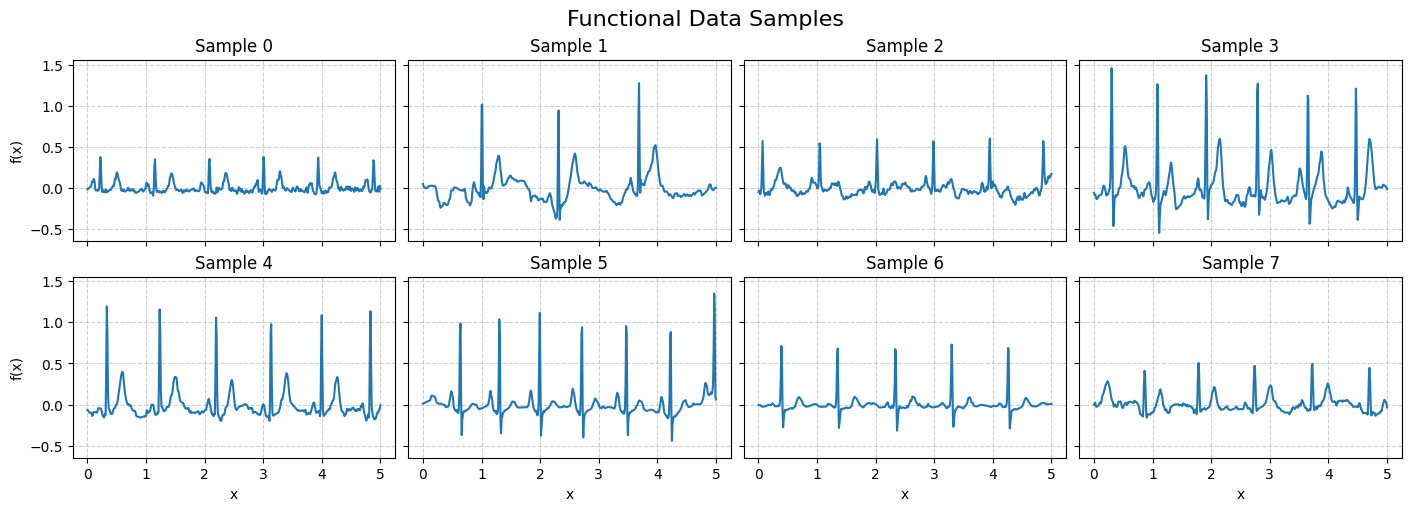

In [ ]:
# Create functional dataset

N, _, M = data_train.shape
x_inf, x_sup = 0.0, 5.0
axis_x = torch.linspace(x_inf, x_sup, M)

# Plot some examples of the dataset

n_examples = 8
examples = torch.stack([data_train[i] for i in range(n_examples)])
print(examples.shape)

plot_function_grid(
    examples,
    n_plots=n_examples,
    axis_x=axis_x,
)

## Flow Matching process

In [ ]:
def alpha_t(t):
    return 1 - t

def diff_alpha_t(t):
    return -1

def beta_t(t):
    return t

def diff_beta_t(t):
    return 1

t_0 = 0.0
T = 1.0
t_eps = 0.0
flow_process = flow.FlowMatchingProcess(
    alpha_t=alpha_t,
    beta_t=beta_t,
    diff_alpha_t=diff_alpha_t,
    diff_beta_t=diff_beta_t,
    t_end=T,
    t_eps=t_eps,
)

torch.Size([3, 100, 1, 500])


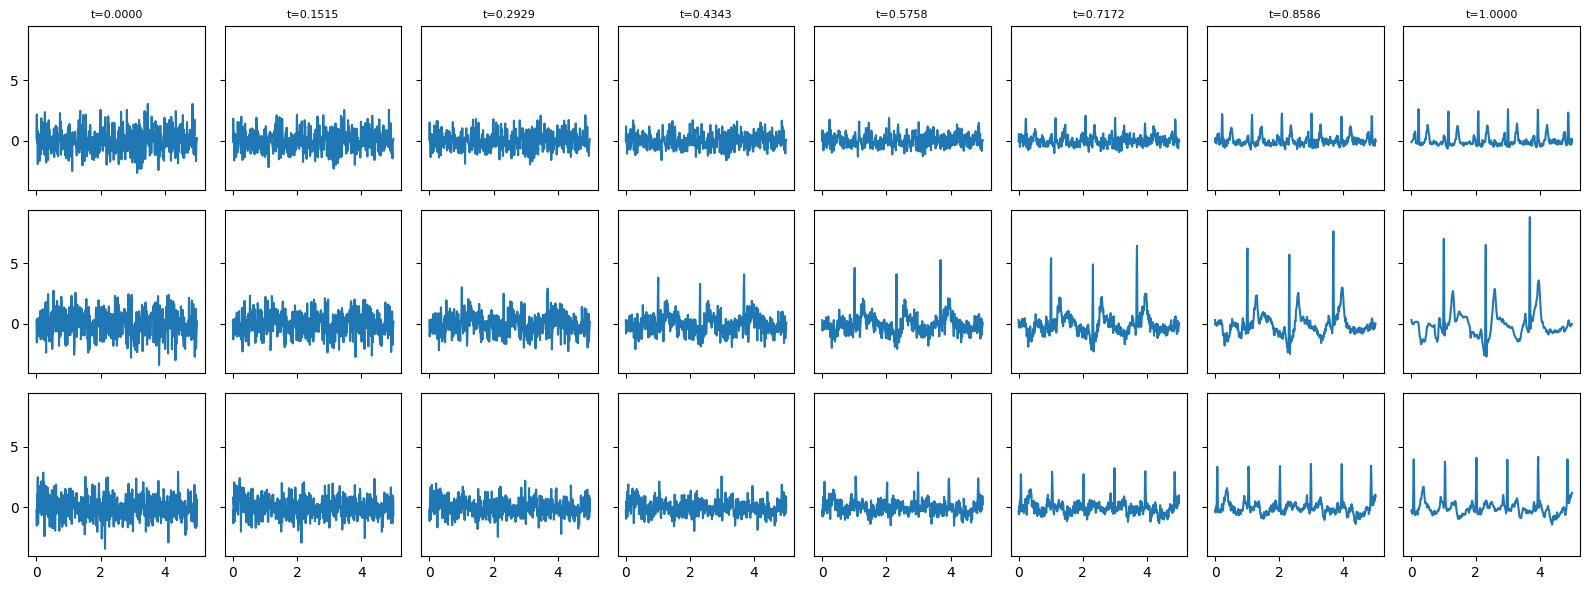

In [ ]:
# Example flow process

n_steps = 100

synthetic_functions_t = flow.flow_interpolation(data_train_norm[:].to(device), alpha_t, beta_t, t_0, T, n_steps)
print(synthetic_functions_t.shape)

plot_flow_process(
    synthetic_functions_t,
    axis_x=axis_x,
    num_steps=8,
    t_start=t_0,
    t_end=T,
)

## Training

In [ ]:
# Define the model

v_model = UNetScoreModel(
    multiply_inv_sigma=None,
    kernel_sizes=kernel_sizes,
    random_state=seed,
    device=device,
)

learning_rate = 1.0e-3
optimizer = Adam(v_model.parameters(), lr=learning_rate)
n_epochs = training_epochs
save_every = max(1, n_epochs // 10)

  0%|          | 0/500 [00:00<?, ?it/s]

Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/checkpoints/training_flow_03_ECG/checkpoint_epoch_1.pth
Epoch: 1. Loss: 795.166984. Time: 00:05
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/checkpoints/training_flow_03_ECG/checkpoint_epoch_50.pth
Epoch: 50. Loss: 341.354146. Time: 03:39
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/checkpoints/training_flow_03_ECG/checkpoint_epoch_100.pth
Epoch: 100. Loss: 312.668179. Time: 07:19
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/checkpoints/training_flow_03_ECG/checkpoint_epoch_150.pth
Epoch: 150. Loss: 303.618424. Time: 10:58
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/checkpoints/training_flow_03_ECG/checkpoint_epoch_200.pth
Epoch: 200. Loss: 295.073797. Time: 14:35
Checkpoint saved

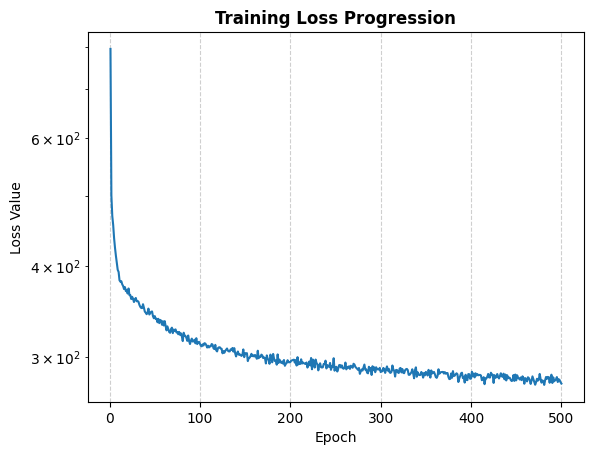

In [ ]:
# Train model

import time
import torchvision.transforms as transforms
import tqdm
from tqdm.notebook import tqdm, trange

batch_size = 32

data_loader = DataLoader(
    data_train_norm,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
)

tqdm_epoch = trange(n_epochs)

loss_history = {
    "epoch": [],
    "loss": []
}

start_time = time.time()
for epoch in tqdm_epoch:
    avg_loss = 0.0
    num_items = 0
    for x in data_loader:
        x = x.to(device)
        loss = flow_process.loss_function(v_model, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    elapsed_time = time.time() - start_time
    tqdm_epoch.set_description('Average Loss: {:5f}'.format(epoch_loss))

    loss_history["epoch"].append(epoch + 1)
    loss_history["loss"].append(epoch_loss)

    if epoch == 0 or (epoch + 1) % save_every == 0:
        save_checkpoint(
            epoch=epoch,
            model=v_model,
            optimizer=optimizer,
            loss=epoch_loss,
            elapsed_time=elapsed_time,
            experiment_name=experiment_name,
            checkpoints_dir=CHECKPOINTS_DIR,
        )

if n_epochs % save_every != 0:
    save_checkpoint(
        epoch=n_epochs - 1,
        model=v_model,
        optimizer=optimizer,
        loss=epoch_loss,
        elapsed_time=elapsed_time,
        experiment_name=experiment_name,
        checkpoints_dir=CHECKPOINTS_DIR,
    )

plot_loss_history(loss_history)

## Synthetic data generation

In [ ]:
# Compute results

results = []

saved_epochs = list(range(save_every, n_epochs + 1, save_every))
saved_epochs = [1] + saved_epochs

checkpoint_paths = [
    os.path.join(
        CHECKPOINTS_DIR,
        experiment_name,
        f"checkpoint_epoch_{epoch}.pth"
    )
    for epoch in saved_epochs
]

def ode(x_t, t, v_model):
    v = v_model(x_t, t)
    return v

n_functions = 9246
torch.manual_seed(seed)
x_0 = torch.randn(n_functions, 1, M, device=device)

n_steps = 100
t_0 = 0.0

for ckpt_path in checkpoint_paths:

    v_model, optimizer, epoch, loss, elapsed_time = load_checkpoint(ckpt_path, v_model, optimizer)
    v_model.eval()

    torch.manual_seed(seed)

    with torch.no_grad():
        times, synthetic_functions_t = flow.euler_integrator(
            x_initial=x_0,
            t_start=t_0,
            t_end=T,
            n_times=n_steps,
            ode_coefficient=partial(ode, v_model=v_model)
        )

    synthetic_functions_norm = synthetic_functions_t[:, -1, :, :]

    synthetic_functions = (synthetic_functions_norm * (data_std + data_eps) + data_mean)

    gen_metrics_df = compute_dataset_metrics(synthetic_functions, fs=SAMPLING_RATE)

    summary = checkpoint_summary(real_ok_df, gen_metrics_df)
    summary = {"epoch": epoch, **summary}

    results.append(summary)

Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/checkpoints/training_flow_03_ECG/checkpoint_epoch_1.pth
Epoch: 1. Loss: 795.166984. Time: 00:05
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/checkpoints/training_flow_03_ECG/checkpoint_epoch_50.pth
Epoch: 50. Loss: 341.354146. Time: 03:39
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/checkpoints/training_flow_03_ECG/checkpoint_epoch_100.pth
Epoch: 100. Loss: 312.668179. Time: 07:19
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/checkpoints/training_flow_03_ECG/checkpoint_epoch_150.pth
Epoch: 150. Loss: 303.618424. Time: 10:58
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/checkpoints/training_flow_03_ECG/checkpoint_epoch_200.pth
Epoch: 200. Loss: 295.073797. Time: 14:35
C

## Results

In [ ]:
df = pd.DataFrame(results)
print(df)

    epoch  success_rate      wd_hr  wd_rr_mean  wd_rr_std
0       1      0.512005   5.301260    0.032932   0.174379
1      50      0.563811   8.051107    0.043601   0.211521
2     100      0.639736   9.382817    0.049969   0.189593
3     150      0.705602  11.189544    0.063822   0.168301
4     200      0.718148  12.574102    0.075172   0.165426
5     250      0.755462  14.250195    0.090335   0.153280
6     300      0.768873  14.705359    0.096284   0.146703
7     350      0.758706  12.091529    0.075543   0.150811
8     400      0.755246  13.128111    0.084438   0.138371
9     450      0.790396  13.944515    0.090670   0.134298
10    500      0.765628  13.281487    0.086193   0.139876


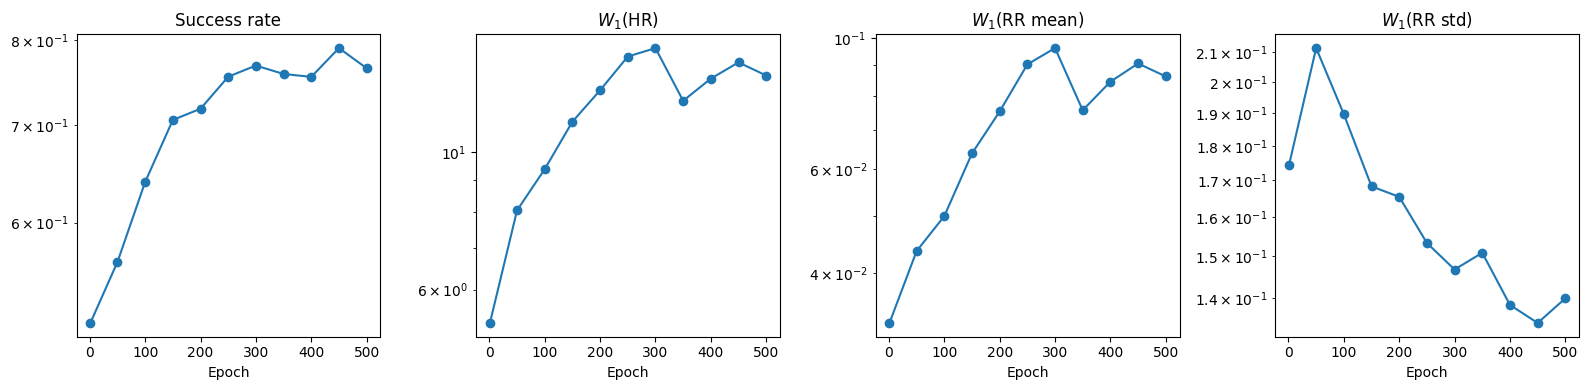

In [ ]:
metrics = ["success_rate", "wd_hr", "wd_rr_mean", "wd_rr_std"]
titles = ["Success rate", r"$W_1$(HR)", r"$W_1$(RR mean)", r"$W_1$(RR std)"]
plot_training_evolution(df, metrics, titles)

R-peak detection success rate — real: 93.1%, generated: 76.6%


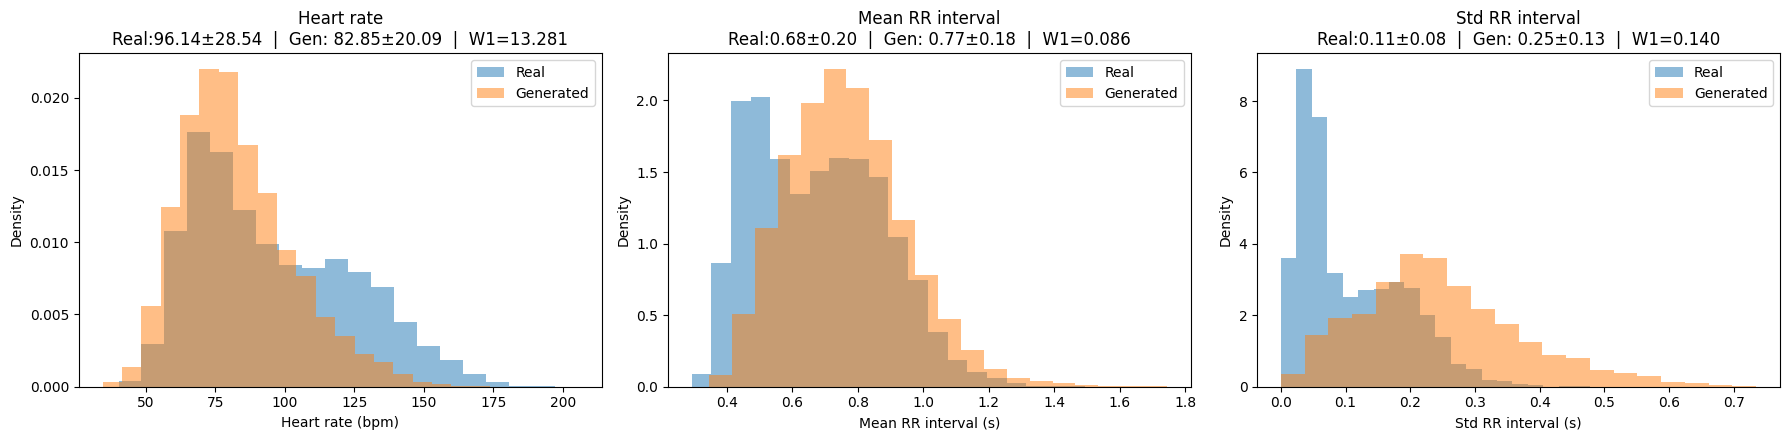

In [ ]:
real_metrics_df = compute_dataset_metrics(data_train, fs=SAMPLING_RATE)
gen_metrics_df = compute_dataset_metrics(synthetic_functions, fs=SAMPLING_RATE)
report = full_report(real_metrics_df, gen_metrics_df)

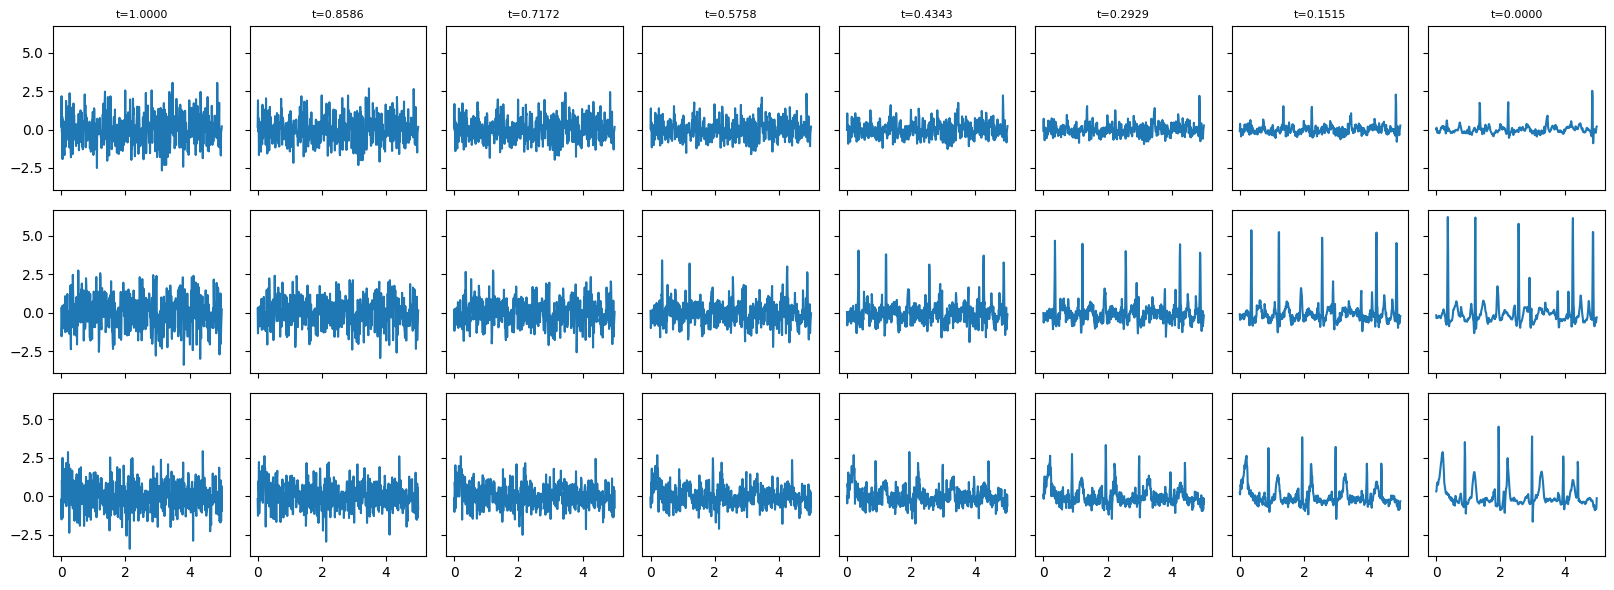

In [ ]:
plot_flow_process(
    synthetic_functions_t,
    axis_x,
    num_steps=8,
    t_start=T,
    t_end=t_0,
)

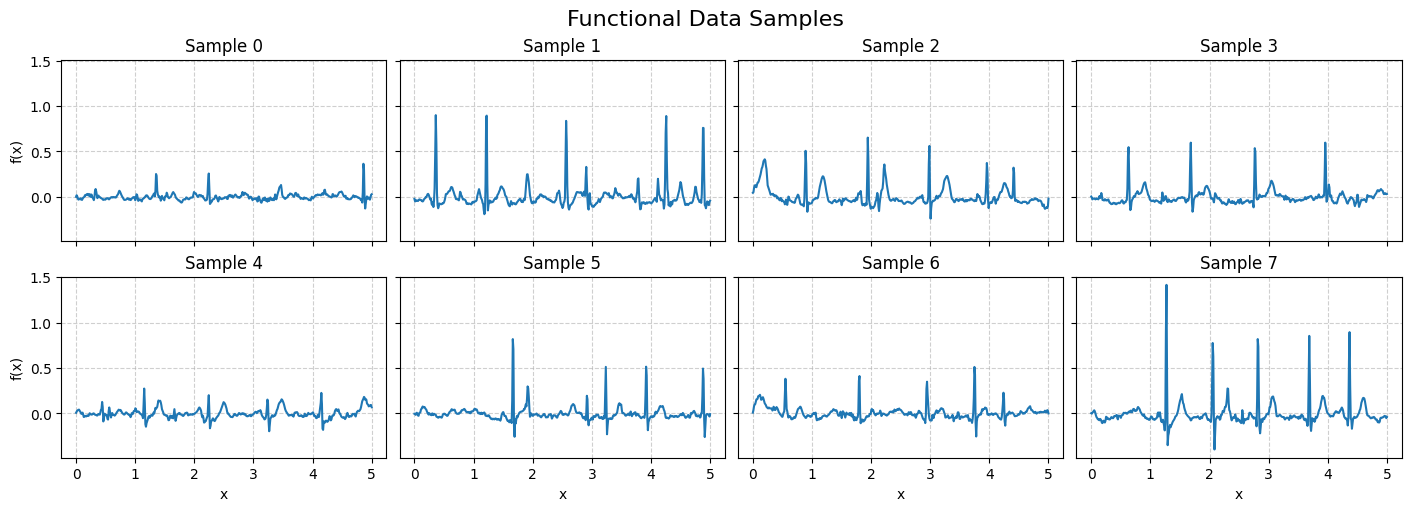

In [ ]:
plot_function_grid(
    synthetic_functions,
    n_plots=8,
    axis_x = axis_x,
)